<a href="https://colab.research.google.com/github/yogidharma21/NoLimit-DS-Test-Yogi-Dharma/blob/main/Nolimit_Data_Science_Test_Yogi_Dharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library & Data

In [1]:
!pip install emoji transformers==4.52.4 sentence-transformers scikit-learn pandas numpy matplotlib seaborn wordcloud imblearn faiss-cpu evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string
import nltk
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import requests
import csv
from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors


import tensorflow as tf
from sentence_transformers import SentenceTransformer
import os

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 1.68M/1.68M [00:00<00:00, 42.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia/versions/1
['review_dana_labelled.csv']


In [5]:
csv_path = os.path.join(
    path,
    "review_dana_labelled.csv"
)

df = pd.read_csv(csv_path)
df.head()

,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  50000 non-null  object
 1   score     50000 non-null  int64 
 2   at        50000 non-null  object
 3   content   50000 non-null  object
 4   sentimen  50000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


## Data Preprocessing

In [7]:
url = "https://raw.githubusercontent.com/ezaaputra/Sentiment-Analysis-Using-BERT/refs/heads/main/kamus_alay.csv"
slangwords = pd.read_csv(url)
slangwords.head()

,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [8]:
def casefoldingtext(text):
    text = text.lower()
    return text

def cleaningtext(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'(\w+)²', r'\1', text)
    text = re.sub(r'\b(\w+)\1\b', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = " ".join([w for w in text.split() if len(w) > 1])
    text = emoji.demojize(text)
    text = re.sub(':[A-Za-z_-]+:', ' ', text)
    text = re.sub(r"([xX;:]'?[dDpPvVoO3)(])", ' ', text)
    text = text.replace('\n', '')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

normalize_word_dict = {}

for _, row in slangwords.iterrows():
    normalize_word_dict[row[0]] = row[1]

def fix_slangwords(text):
    words = word_tokenize(text)

    words = [
        normalize_word_dict[word]
        if word in normalize_word_dict
        else word
        for word in words
    ]

    return " ".join(words)

/tmp/ipykernel_483/3717972429.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalize_word_dict[row[0]] = row[1]


In [9]:
teks = "  akuuuu mau      memberi makan gaga tidak berguna      "
tokens = word_tokenize(teks)
print(cleaningtext(teks))

aku mau memberi makan ga tidak berguna


In [10]:
df['text_casefolding'] = df['content'].apply(casefoldingtext)

df['text_clean'] = df['text_casefolding'].apply(cleaningtext)

df['text_final'] = df['text_clean'].apply(fix_slangwords)

In [11]:
df.head()

,userName,score,at,content,sentimen,text_casefolding,text_clean,text_final
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE,bagus,bagus,bagus
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE,dana mmg keren mantap.,dana mmg keren mantap,dana memang keren mantap
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE,saya ngajuin upgrade dana premium krna ktp say...,saya ngajuin upgrade dana premium krna ktp say...,saya mengajukan upgrade dana premium karena kt...
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE,kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon nya ml malah eror segala kag...
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE,saldo hilang karena no lama hilang ganti no sa...,saldo hilang karena no lama hilang ganti no sa...,saldo hilang karena no lama hilang ganti no sa...


In [12]:
df.to_csv("Clean DataSet Review App Spotify.csv", index=False)

## EDA

In [13]:
df['sentimen'].value_counts()

,count
sentimen,
POSITIVE,26555
NEGATIVE,17073
NEUTRAL,6372


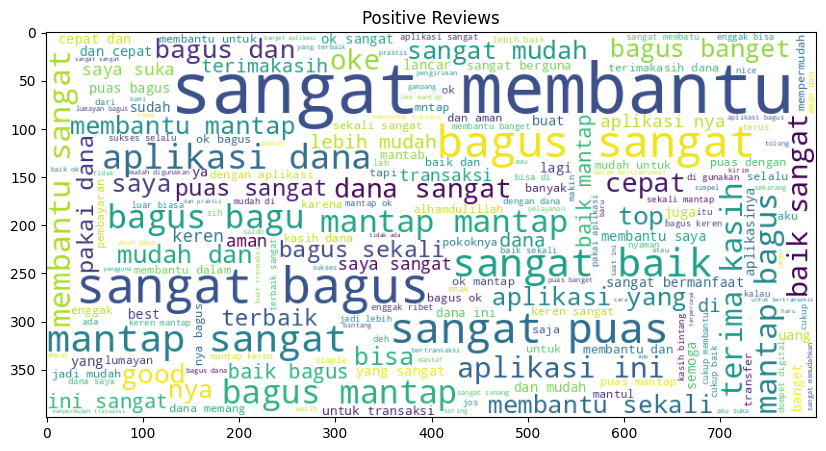

In [14]:
positive_text = " ".join(
    df[df['sentimen'] == 'POSITIVE']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('Positive Reviews')
plt.show()

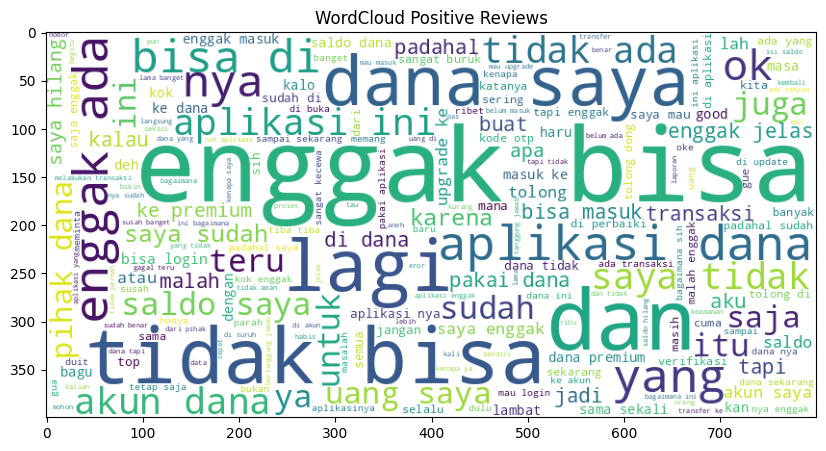

In [15]:
positive_text = " ".join(
    df[df['sentimen'] == 'NEGATIVE']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('WordCloud Positive Reviews')
plt.show()

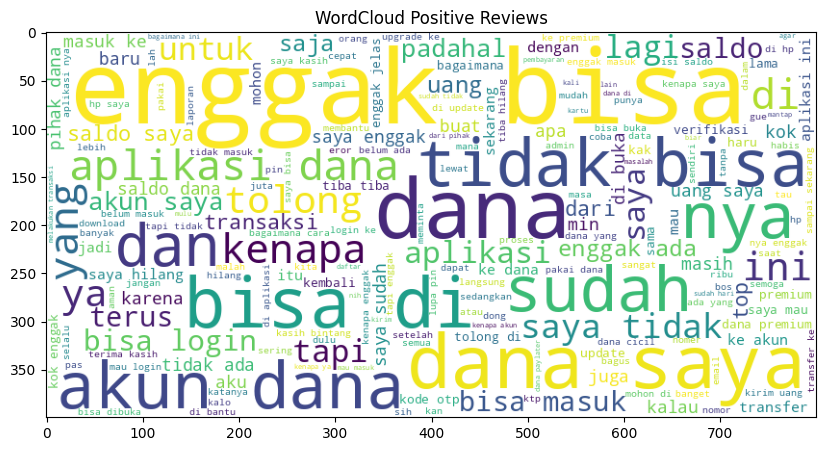

In [16]:
positive_text = " ".join(
    df[df['sentimen'] == 'NEUTRAL']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('WordCloud Positive Reviews')
plt.show()

## Data Spliting

In [17]:
X = df["text_final"]
y = df["sentimen"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)

y_test = le.transform(y_test)

In [19]:
print(dict(zip(
    le.classes_,
    le.transform(le.classes_)
)))

{'NEGATIVE': np.int64(0), 'NEUTRAL': np.int64(1), 'POSITIVE': np.int64(2)}


In [20]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(13658), np.int64(1): np.int64(5098), np.int64(2): np.int64(21244)}


## Build Model Sentence Transformer


In [21]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.9762288280372919), np.int64(1): np.float64(2.6154047338825683), np.int64(2): np.float64(0.6276281930584322)}


In [22]:
embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-large"
)

X_train_emb = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_emb = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_emb.shape[1],)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(3, activation='softmax')
])

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_emb,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
563/563 [==============================] - 8s 6ms/step - loss: 0.5837 - accuracy: 0.7786 - val_loss: 0.4621 - val_accuracy: 0.8253
Epoch 2/20
563/563 [==============================] - 4s 6ms/step - loss: 0.5176 - accuracy: 0.8056 - val_loss: 0.4750 - val_accuracy: 0.8025
Epoch 3/20
563/563 [==============================] - 3s 5ms/step - loss: 0.5012 - accuracy: 0.8102 - val_loss: 0.4616 - val_accuracy: 0.8110
Epoch 4/20
563/563 [==============================] - 3s 5ms/step - loss: 0.4920 - accuracy: 0.8166 - val_loss: 0.4726 - val_accuracy: 0.8092
Epoch 5/20
563/563 [==============================] - 4s 6ms/step - loss: 0.4838 - accuracy: 0.8199 - val_loss: 0.4470 - val_accuracy: 0.8173
Epoch 6/20
563/563 [==============================] - 3s 6ms/step - loss: 0.4759 - accuracy: 0.8215 - val_loss: 0.4538 - val_accuracy: 0.8130
Epoch 7/20
563/563 [==============================] - 3s 6ms/step - loss: 0.4715 - accuracy: 0.8216 - val_loss: 0.4367 - val_accuracy: 0.8230
Epoch 

In [36]:
loss, acc = model.evaluate(
    X_test_emb,
    y_test
)

print("Accuracy:", acc)

313/313 [==============================] - 2s 6ms/step - loss: 0.4212 - accuracy: 0.8264
Accuracy: 0.8263999819755554


## Similarity Search

In [27]:
nn = NearestNeighbors(
    n_neighbors=5,
    metric='cosine'
)

nn.fit(X_train_emb)

NearestNeighbors(metric='cosine')

In [28]:
query = "aplikasi dana sering error saat transfer"

query_emb = embedding_model.encode([query])

distances, indices = nn.kneighbors(query_emb)

In [29]:
for idx in indices[0]:
    print(X_train.iloc[idx])

sering error dana enggak bisa loginerror lagi
kacau aplikasi dana sering bermasalah
aplikasi dana sekarang sering kecolongan
mengapa saat mau update dana selalu gagal
aplikasi dana sangat buruk di perlambat isi saldo


In [30]:
query = "saldo hilang setelah transaksi"

query_emb = embedding_model.encode([query])

distances, indices = nn.kneighbors(query_emb)

In [31]:
for idx in indices[0]:
    print(X_train.iloc[idx])

saldo hilang tanpa transaksi saya sendiri
saldo hilang padahal saya tidak melakukan transaksi
saldo hilang
saldo hilang
saldo hilang


In [32]:
sample = "aplikasi sangat membantu dan mudah digunakan"

sample_emb = embedding_model.encode([sample])

pred = model.predict(sample_emb)

label = le.inverse_transform(
    [np.argmax(pred)]
)[0]

print("Review :", sample)
print("Prediksi :", label)

1/1 [==============================] - 0s 29ms/step
Review : aplikasi sangat membantu dan mudah digunakan
Prediksi : POSITIVE


## Save Model

In [39]:
import joblib

joblib.dump(le, "label_encoder.pkl")
joblib.dump(nn, "nearest_neighbors.pkl")

model.save("sentiment_model.keras")

In [40]:
joblib.dump(
    X_train,
    "reviews.pkl"
)

['reviews.pkl']